In [2]:
import subprocess
subprocess.run(["pip", "install", "--user", "pandas", "matplotlib", "seaborn", "pandasql"], check=True)

CompletedProcess(args=['pip', 'install', '--user', 'pandas', 'matplotlib', 'seaborn', 'pandasql'], returncode=0)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create useful calculated columns
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

print("Cleaned shape:", df.shape)
print("\nNew columns added: Order Year, Order Month, Profit Margin")
print("\nProfit Margin stats:")
print(df['Profit Margin'].describe())

Cleaned shape: (9994, 24)

New columns added: Order Year, Order Month, Profit Margin

Profit Margin stats:
count    9994.000000
mean       12.031390
std        46.675436
min      -275.000000
25%         7.500000
50%        27.000000
75%        36.250000
max        50.000000
Name: Profit Margin, dtype: float64


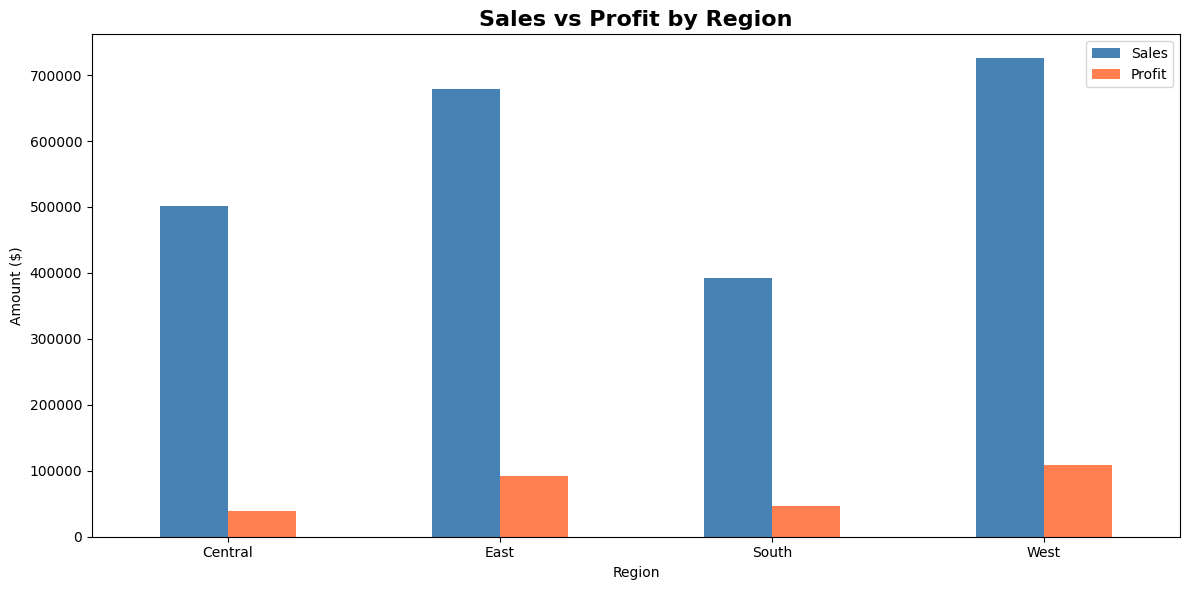

    Region  Total_Sales  Total_Profit  Profit_Margin_Pct
0     West    725457.82     108418.45              14.94
1     East    678781.24      91522.78              13.48
2    South    391721.91      46749.43              11.93
3  Central    501239.89      39706.36               7.92


In [5]:
# ---- ANALYSIS 1: Sales and Profit by Region ----
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)

region_perf.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'coral'])
plt.title('Sales vs Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.savefig('chart1_region_performance.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT Region,
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(SUM(Profit) / SUM(Sales) * 100, 2) AS Profit_Margin_Pct
FROM df
GROUP BY Region
ORDER BY Total_Profit DESC
"""
result = sqldf(query, locals())
print(result)

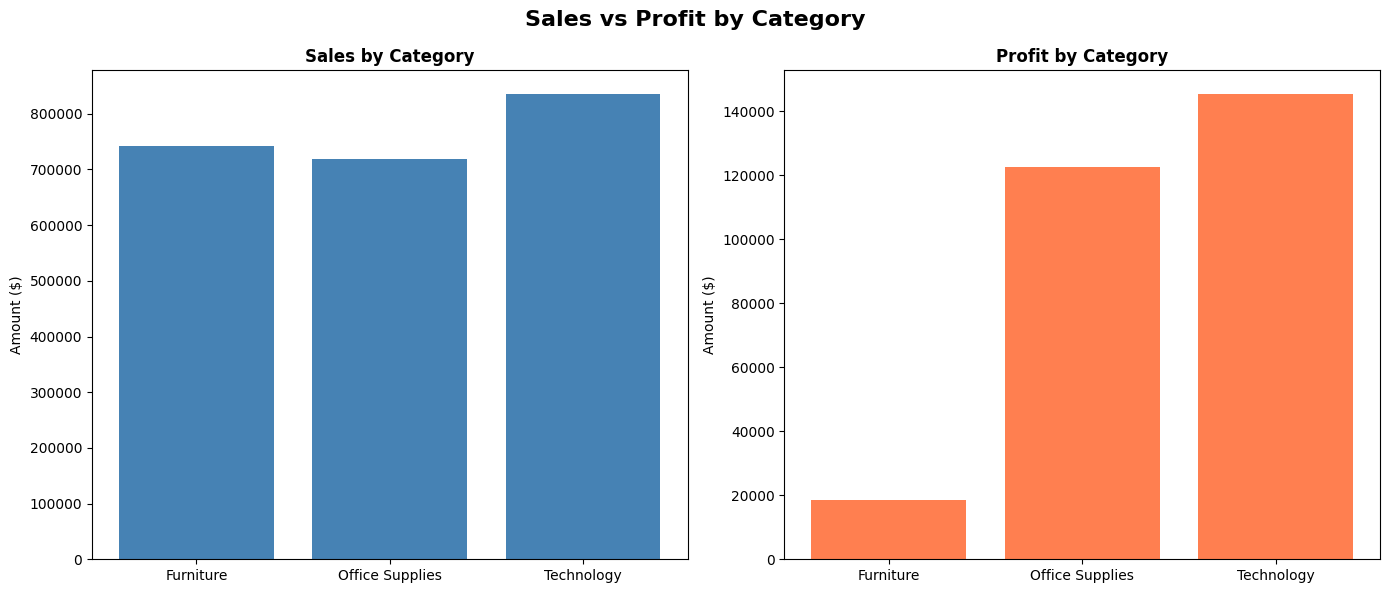

          Category  Total_Sales  Total_Profit  Profit_Margin_Pct
0       Technology    836154.03     145454.95              17.40
1  Office Supplies    719047.03     122490.80              17.04
2        Furniture    741999.80      18451.27               2.49


In [6]:
# ---- ANALYSIS 2: Profit by Category and Sub-Category ----
category_perf = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by category
axes[0].bar(category_perf.index, category_perf['Sales'], color='steelblue')
axes[0].set_title('Sales by Category', fontweight='bold')
axes[0].set_ylabel('Amount ($)')

# Profit by category
axes[1].bar(category_perf.index, category_perf['Profit'], color='coral')
axes[1].set_title('Profit by Category', fontweight='bold')
axes[1].set_ylabel('Amount ($)')

plt.suptitle('Sales vs Profit by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_category_performance.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT Category,
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(SUM(Profit) / SUM(Sales) * 100, 2) AS Profit_Margin_Pct
FROM df
GROUP BY Category
ORDER BY Total_Profit DESC
"""
result = sqldf(query, locals())
print(result)

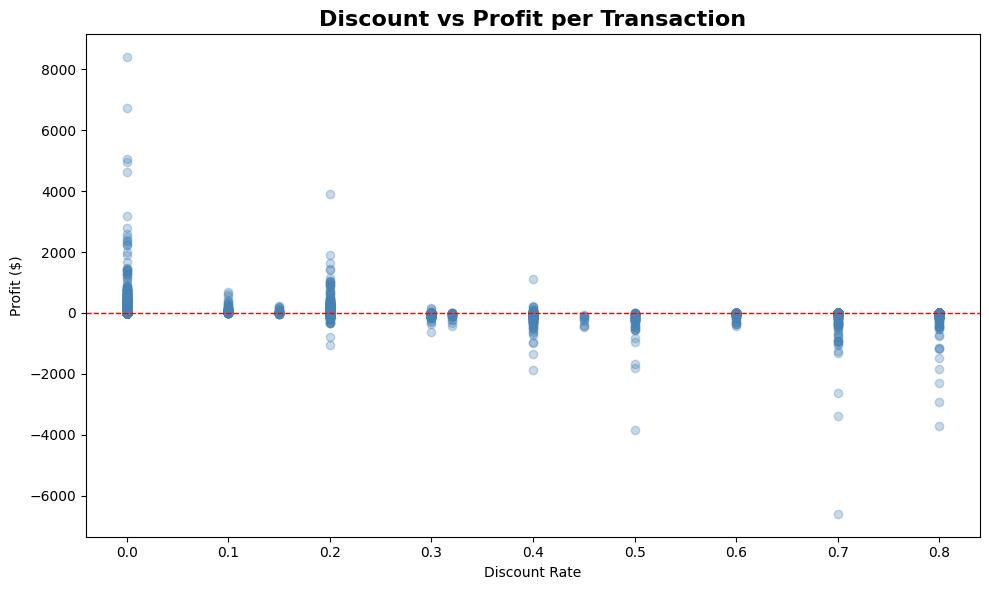

     Discount_Band  Total_Orders  Total_Profit  Avg_Profit_Per_Order
0      No Discount          4798     320987.60                 66.90
1      Low (0-20%)          3803     100785.47                 26.50
2  Medium (20-40%)           460     -35817.47                -77.86
3      High (40%+)           933     -99558.59               -106.71


In [7]:
# ---- ANALYSIS 3: Impact of Discount on Profit ----
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit per Transaction', fontsize=16, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('chart3_discount_vs_profit.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT 
    CASE 
        WHEN Discount = 0 THEN 'No Discount'
        WHEN Discount <= 0.2 THEN 'Low (0-20%)'
        WHEN Discount <= 0.4 THEN 'Medium (20-40%)'
        ELSE 'High (40%+)'
    END AS Discount_Band,
    COUNT(*) AS Total_Orders,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(AVG(Profit), 2) AS Avg_Profit_Per_Order
FROM df
GROUP BY Discount_Band
ORDER BY Total_Profit DESC
"""
result = sqldf(query, locals())
print(result)

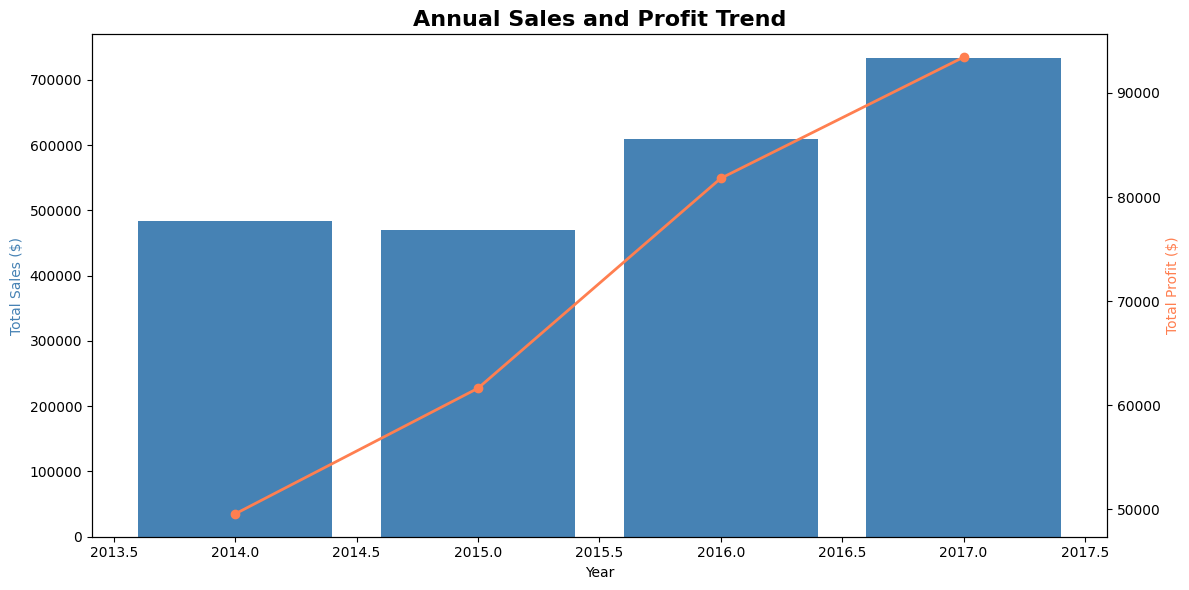

   Order Year  Total_Sales  Total_Profit  Profit_Margin_Pct
0        2014    484247.50      49543.97              10.23
1        2015    470532.51      61618.60              13.10
2        2016    609205.60      81795.17              13.43
3        2017    733215.26      93439.27              12.74


In [8]:
# ---- ANALYSIS 4: Sales Trend by Year ----
yearly_sales = df.groupby('Order Year')[['Sales', 'Profit']].sum().round(2)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(yearly_sales.index, yearly_sales['Sales'], color='steelblue', label='Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales ($)', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly_sales.index, yearly_sales['Profit'], color='coral', 
         marker='o', linewidth=2, label='Profit')
ax2.set_ylabel('Total Profit ($)', color='coral')

plt.title('Annual Sales and Profit Trend', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('chart4_annual_trend.png', dpi=150)
plt.show()

# ---- SQL ----
query = """
SELECT [Order Year],
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS Profit_Margin_Pct
FROM df
GROUP BY [Order Year]
ORDER BY [Order Year] ASC
"""
result = sqldf(query, locals())
print(result)

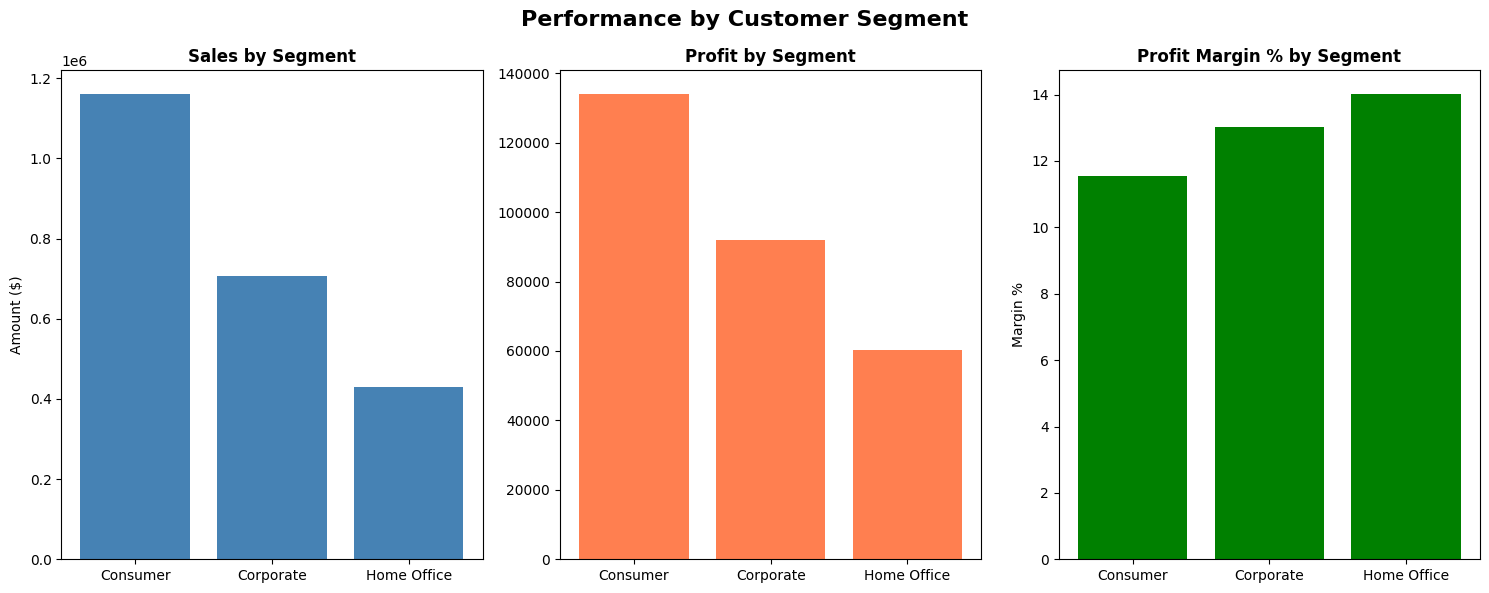

       Segment  Total_Sales  Total_Profit  Profit_Margin_Pct  Total_Orders
0     Consumer   1161401.34     134119.21              11.55          2586
1    Corporate    706146.37      91979.13              13.03          1514
2  Home Office    429653.15      60298.68              14.03           909


In [9]:
# ---- ANALYSIS 5: Profit by Customer Segment ----
segment_perf = df.groupby('Segment')[['Sales', 'Profit']].sum().round(2)
segment_perf['Profit_Margin'] = (segment_perf['Profit'] / segment_perf['Sales'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].bar(segment_perf.index, segment_perf['Sales'], color='steelblue')
axes[0].set_title('Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Amount ($)')

axes[1].bar(segment_perf.index, segment_perf['Profit'], color='coral')
axes[1].set_title('Profit by Segment', fontweight='bold')

axes[2].bar(segment_perf.index, segment_perf['Profit_Margin'], color='green')
axes[2].set_title('Profit Margin % by Segment', fontweight='bold')
axes[2].set_ylabel('Margin %')

plt.suptitle('Performance by Customer Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_segment_performance.png', dpi=150)
plt.show()

# ---- SQL ----
query = """
SELECT Segment,
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS Profit_Margin_Pct,
       COUNT(DISTINCT [Order ID]) AS Total_Orders
FROM df
GROUP BY Segment
ORDER BY Total_Profit DESC
"""
result = sqldf(query, locals())
print(result)